In [19]:
import emcee
import numpy as np
import matplotlib.pyplot as plt
import corner


THE TRANSIENT UNIVERSE

In [20]:
data = np.load("transient.npy")
#first column is time, second column is flux and the third column is the error on the flux (homoskedastic errors)


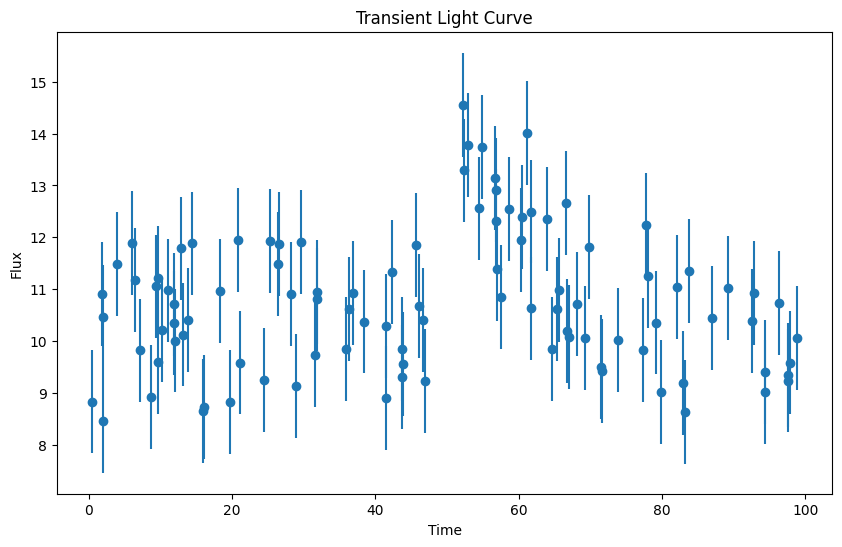

In [21]:
#make a plot of the data with error bars
plt.figure(figsize=(10,6))
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2], fmt='o')
plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Transient Light Curve")
plt.show()  

In [22]:
# Model for the data, sharp burst with an exponenetial tail rising above a constant background. 
# The model has 4 parameters: the time of the burst t0, the amplitude of the burst A, the decay time of the burst alphaand the background amplitude B

def Model(t, t0, A, alpha, B):
    # Clip the math inside the exponent so it doesn't blow up to infinity
    arg = -(t - t0) * alpha
    safe_arg = np.clip(arg, -700, 700) 
    
    return A * np.exp(safe_arg) * (t >= t0) + B

# Define log-likelihood that take in input the array parameters of the model and the array of data (neglect the constant term)
def Log_Likelihood(theta, data):
    t0, A, alpha, B = theta
    t=data[:,0]
    y=data[:,1]
    yerr=data[:,2]
    model_flux = Model(t, t0, A, alpha, B)
    return -0.5 * np.sum(((y - model_flux) / yerr) ** 2)

# Define a prior on the parameters of the model. We assume that the parameters are uniformly distributed in a reasonable range.
#alpha is uniform in log space, so the prior on alpha is proportional to 1/alpha, which means that the log-prior is -log(alpha)
def Log_Prior(theta):
    t0, A, alpha, B = theta
    
    if (alpha > 0) and (np.min(data[:,0]) < t0 < np.max(data[:,0])) and (0 < A < 50) and (0 < B < 50):
        
        ln_alpha = np.log(alpha)
        if -5 < ln_alpha < 5:
            return -ln_alpha  # This is the log of (1/alpha)
            
    return -np.inf

def Log_Posterior(theta, data):
    return Log_Prior(theta) + Log_Likelihood(theta, data)


In [23]:
# Set the MCMC sampler parameters
ndim = 4  # number of parameters in the model
nwalkers = 20  # number of MCMC walkers
nsteps = 1000000  # number of MCMC steps to take

# each walker needs a starting point in the parameter space, so we need to create an array of shape (nwalkers, ndim) that contains the starting points for each walker.

starting_guesses = np.zeros((nwalkers, ndim))
# Set the initial guess for the parameters of the model. We can use prior knowledge about the parameters to set the initial guess, or we can use random values within a reasonable range.
for i in range(nwalkers):
    starting_guesses[i] = [
        np.random.uniform(np.min(data[:,0]), np.max(data[:,0])), # t0
        np.random.uniform(0, 50),                           # A
        np.exp(np.random.uniform(-4.9, 4.9)),                        # alpha
        np.random.uniform(0, 50)                            # B
    ]

theta = np.zeros((ndim,))

# Starting guess for the MCMC run
t0_quick=50
A_quick=5
b_quick=10
alpha_quick=0.1

theta_quick = np.array([t0_quick, A_quick, alpha_quick, b_quick])
starting_guesses = theta_quick + 1e-1 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, Log_Posterior, args=[data])
sampler.run_mcmc(starting_guesses, nsteps, progress=True)



  0%|          | 0/1000000 [00:00<?, ?it/s]/Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and Machine Learning/astrostatistics_bicocca_2025-main/.venv/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 1000000/1000000 [1:27:54<00:00, 189.61it/s]   


State([[48.12545121  8.95444812  0.16404664 10.17731975]
 [47.28722033  8.13556379  0.13995127 10.50127026]
 [48.98001507  5.51906273  0.10158496 10.36595032]
 [51.08462078  5.01815225  0.13719352 10.39651131]
 [48.0599489   6.67837721  0.10207848 10.19258272]
 [47.62250555  6.69543669  0.12871145 10.21640589]
 [51.32495811  4.48114357  0.13993251 10.35046227]
 [51.29303242  3.95170248  0.10127922 10.29178707]
 [48.12128764  9.15070659  0.16458106 10.39983895]
 [49.71527201  4.52128776  0.08531797 10.19229473]
 [50.00414229  4.7374783   0.09711246 10.1733959 ]
 [48.82492572  9.77425337  0.21512275 10.40080874]
 [47.37239338  6.91752093  0.13859926 10.50901241]
 [49.63928275  5.68312416  0.13545625 10.21294038]
 [51.52273979  3.22395795  0.0994682  10.17153245]
 [50.78851858  3.97263805  0.10414168 10.17998562]
 [48.80802502  8.13422559  0.16220057 10.38522497]
 [49.30810705  6.07213817  0.13025282 10.34155802]
 [47.0247099   6.76837697  0.12404163 10.37337854]
 [47.60378991  8.38860387

In [24]:
#Perform an appropriate burn-in and thinning of the MCMC chain, and plot the posterior distribution of the parameters of the model.
tau = sampler.get_autocorr_time()
burn_in = int(3 * np.max(tau))  # number of steps to discard as burn-in
thin = int (np.max(tau)) # thinning factor to reduce the correlation between samples
# get the MCMC chain after burn-in and thinning
emcee_trace = sampler.get_chain(discard=burn_in, thin=thin, flat=True)




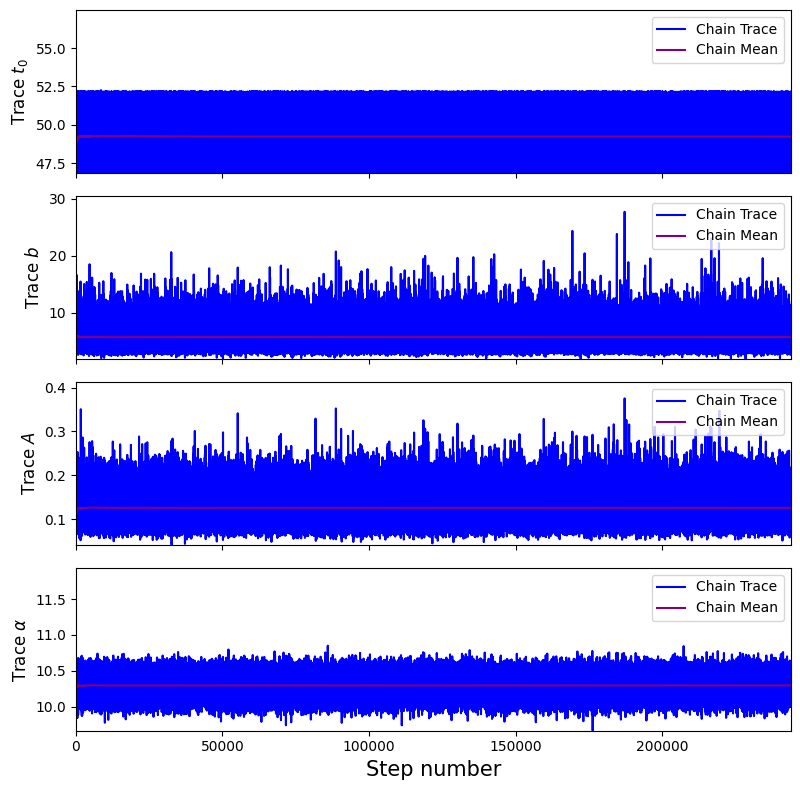

In [ ]:
# Plot the traces
M = emcee_trace.shape[0]  

fig, axes = plt.subplots(ndim, 1, figsize=(8, 2 * ndim), sharex=True)

xgrid = np.linspace(1, M, M)

#cumulative mean
meanC = np.array([np.cumsum(emcee_trace[:, i]) / (np.arange(M) + 1) for i in range(ndim)])

# traces
labels = [r'$t_0$', r'$b$', r'$A$', r'$\alpha$']
for i in range(ndim):
    axes[i].plot(xgrid, emcee_trace[:, i], color='blue', label='Chain Trace')
    axes[i].plot(xgrid, meanC[i], color='purple', label='Chain Mean')

    axes[i].set_ylabel(f'Trace {labels[i]}', fontsize=12)
    axes[i].axis([0, M, np.min(emcee_trace[:, i]), 1.1 * np.max(emcee_trace[:, i])])
    axes[i].legend(fontsize=10, loc='upper right')

plt.xlabel('Step number', fontsize=15)

plt.tight_layout()
plt.show()

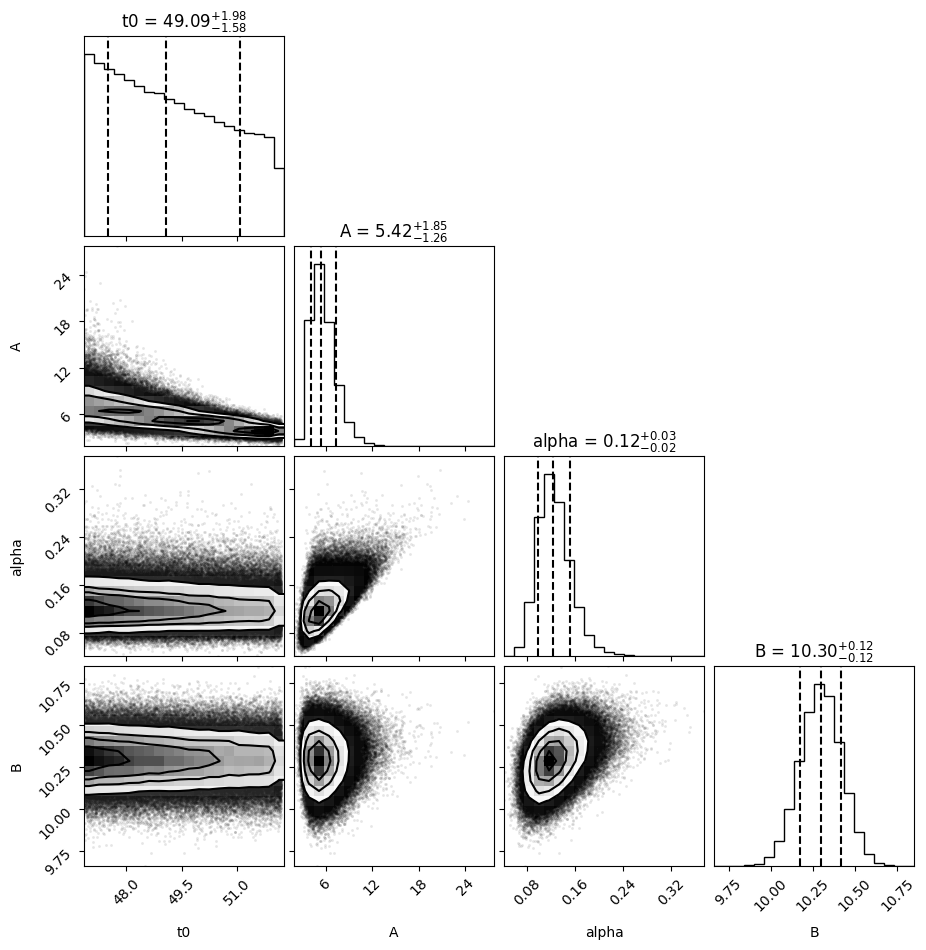

In [26]:
# Corner plot of the posterior distribution of the parameters of the model
# show also the  68% in red and 95% in blue credible intervals for each parameter in the corner plot
fig = corner.corner(emcee_trace, labels=["t0", "A", "alpha", "B"], show_titles=True, title_fmt=".2f", quantiles=[0.16, 0.5, 0.84], title_kwargs={"fontsize": 12})
plt.show()  

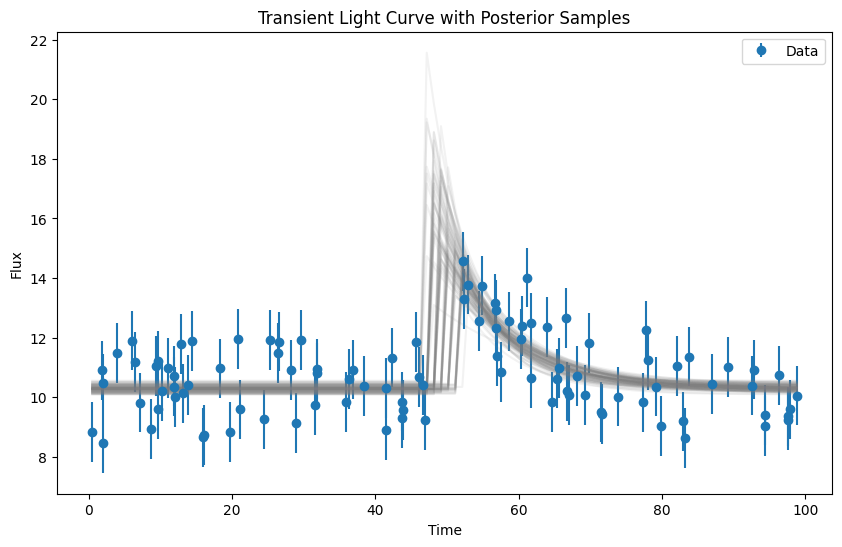

In [27]:
# Choose 100 random samples from the MCMC chain and plot the corresponding burst time series on top of the data to visualize the fit of the model to the data.
# these are showimg the posterio spread solution that are consistent with the data, so we can see how well the model fits the data and how much uncertainty there is in the parameters of the model.
plt.figure(figsize=(10,6))
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2], fmt='o', label='Data')
t_fit = np.linspace(np.min(data[:,0]), np.max(data[:,0]), 100)
for i in range(100):
    sample = emcee_trace[np.random.randint(len(emcee_trace))] # randomly select a sample from the MCMC chain
    t0_sample, A_sample, alpha_sample, B_sample = sample 
    model_flux_sample = Model(t_fit, t0_sample, A_sample, alpha_sample, B_sample)
    plt.plot(t_fit, model_flux_sample, color='gray', alpha=0.1)
plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Transient Light Curve with Posterior Samples")
plt.legend()
plt.show()


In [28]:
# Print the results
labels = [r"t0", r"A", r"alpha", r"B"]

print("Result (Median + 90% Credible Region):")
print("-" * 40)

for i in range(ndim):
    
    q_5, q_median, q_95 = np.percentile(emcee_trace[:, i], [5, 50, 95])
    
    
    plus_error = q_95 - q_median
    minus_error = q_median - q_5
    
    print(f"{labels[i]} = {q_median:.4f} +{plus_error:.4f} -{minus_error:.4f}")

print("-" * 40)

Result (Median + 90% Credible Region):
----------------------------------------
t0 = 49.0860 +2.7314 -2.0266
A = 5.4213 +3.3995 -1.8231
alpha = 0.1226 +0.0528 -0.0369
B = 10.2969 +0.1988 -0.2029
----------------------------------------
